In [1]:
import numpy as np
import sys
import os
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass

In [2]:
sys.path.append(os.path.abspath('../library'))
import data as d
import preprocess as p
import utils as u
import bayes as b
import pipeline
import results as r
import figures as figs

In [3]:
mouse_ID = 'C57_913_Qiu'
Qiu_200 = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID, tau=0.2)))
Qiu_200.tau = 0.2 # size of time bin of the data in seconds
Qiu_200.rewardzone = [46,47,48,49]

scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_913_Qiu/time_binned_SpikeInf_200msbins.mat loaded with mat73.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_913_Qiu/time_binned_DiscreteSpikes_200msbins.mat loaded with mat73.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_913_Qiu/target_positions_200msbins.mat loaded with mat73.loadmat
../datafiles/C57_913_Qiu/darktrial_raw.mat loaded with scipy.io.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_913_Qiu/del_trials.mat loaded with mat73.loadmat

Data of: C57_913_Qiu

Spike Probability:
(244, 112, 125)
Trial x 100ms Time Bin x Neuron

Discrete Spikes:
(244, 112, 125)
Trial x 100ms Time Bin x Neuron

Position Matrices:
(244, 

In [12]:
mouse_ID = 'C57_913_Qiu'
Qiu_100 = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID, tau=0.1)))
Qiu_100.tau = 0.1 # size of time bin of the data in seconds
Qiu_100.rewardzone = [46,47,48,49]

scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_913_Qiu/time_binned_SpikeInf.mat loaded with mat73.loadmat
../datafiles/C57_913_Qiu/time_binned_DiscreteSpikes.mat loaded with scipy.io.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_913_Qiu/target_positions.mat loaded with mat73.loadmat
../datafiles/C57_913_Qiu/darktrial_raw.mat loaded with scipy.io.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_913_Qiu/del_trials.mat loaded with mat73.loadmat

Data of: C57_913_Qiu

Spike Probability:
(244, 223, 125)
Trial x 100ms Time Bin x Neuron

Discrete Spikes:
(244, 223, 125)
Trial x 100ms Time Bin x Neuron

Position Matrices:
(244, 223)
Trial x 100ms Time Bin

Dark Trials:
(244, 1)
Trial, (0=light, 1=dark)

Deleted Trials:
(13,)
Trial, (Trial_Num of deleted tria

In [4]:
pipeline.get_tuning_curves(Qiu_200, 5, 50, 0.2)

1. Masking spikes and position matrix.
smallest first position: 0.0
largest first position: 34.0
2. Getting trial length.
3. Smoothing spikes.
sigma: 1.0, smoothfactor: 0.2
4. Position Binning data and generating firing rates.


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


5. Splitting light vs dark.
6. Scaling firing rates.
higher in dark: 49 | 39.2 %
higher in light: 76 | 60.8 %
higher in dark: 50 | 40.0 %
higher in light: 75 | 60.0 %


In [14]:
pipeline.get_tuning_curves(Qiu_100, 5, 50, 0.2)

1. Masking spikes and position matrix.
smallest first position: 0.0
largest first position: 34.0
2. Getting trial length.
3. Smoothing spikes.
sigma: 2.0, smoothfactor: 0.2
4. Position Binning data and generating firing rates.


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


5. Splitting light vs dark.
6. Scaling firing rates.
higher in dark: 52 | 41.6 %
higher in light: 73 | 58.4 %
higher in dark: 52 | 41.6 %
higher in light: 73 | 58.4 %


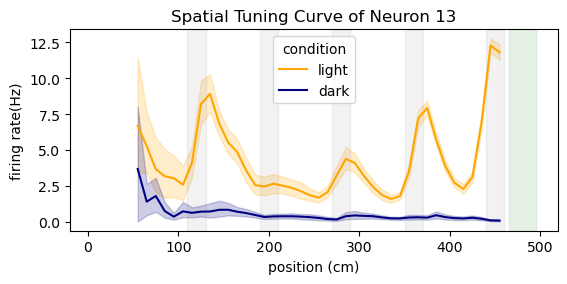

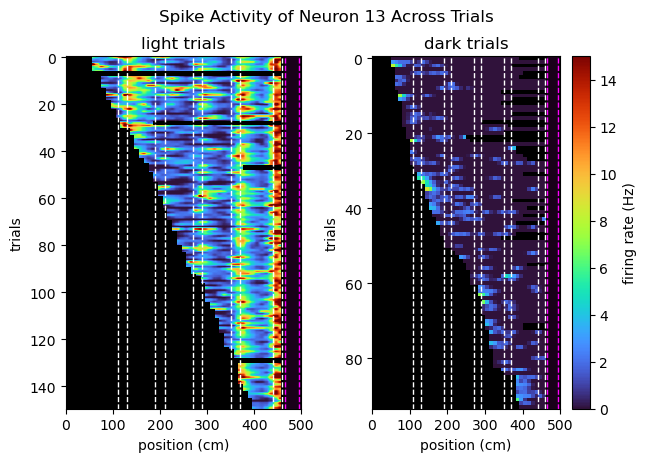

In [16]:
figs.plot_single_tuning(Qiu_100, Qiu_100.fr_smoothed, 'spikes', neuron_idx=13)
figs.plot_single_heatmap(Qiu_100, Qiu_100.fr_smoothed, 'spikes', neuron_idx=13)

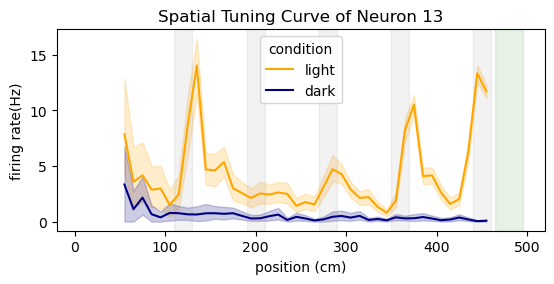

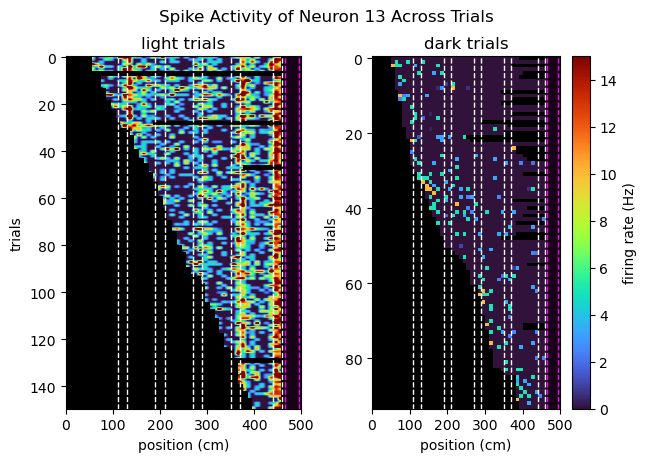

In [17]:
figs.plot_single_tuning(Qiu_100, Qiu_100.fr, 'spikes', neuron_idx=13)
figs.plot_single_heatmap(Qiu_100, Qiu_100.fr, 'spikes', neuron_idx=13)

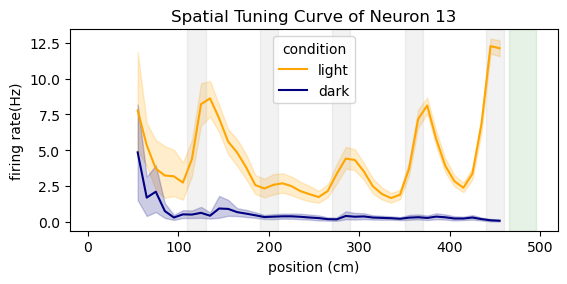

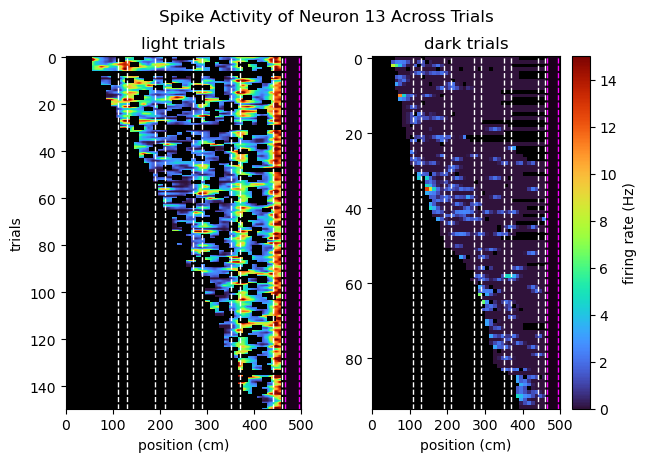

In [15]:
figs.plot_single_tuning(Qiu_200, Qiu_200.fr_smoothed, 'spikes', neuron_idx=13)
figs.plot_single_heatmap(Qiu_200, Qiu_200.fr_smoothed, 'spikes', neuron_idx=13)

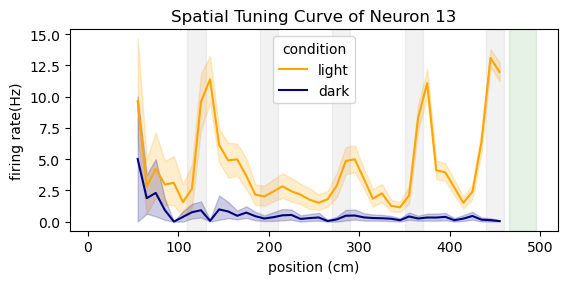

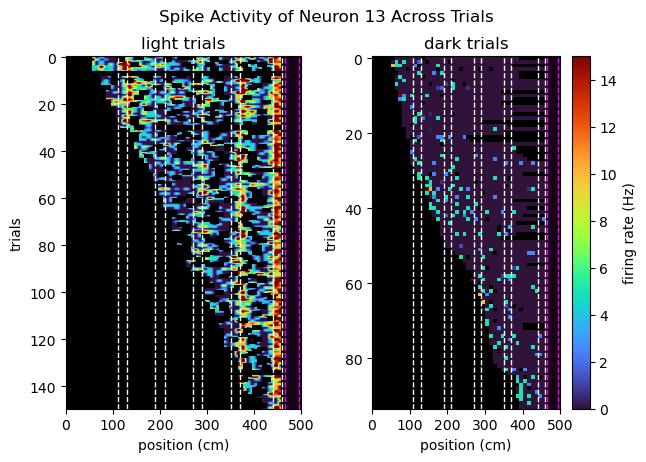

In [11]:
figs.plot_single_tuning(Qiu_200, Qiu_200.fr, 'spikes', neuron_idx=13)
figs.plot_single_heatmap(Qiu_200, Qiu_200.fr, 'spikes', neuron_idx=13)

In [10]:
Qiu_200.fr_light[0,:,13]

array([        nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
        0.        ,  0.        , 10.        , 15.        ,  5.        ,
        0.        , 10.        ,  2.5       ,  5.        ,  0.        ,
        0.        ,  5.        ,  0.        ,         nan,  0.        ,
        5.        ,  0.        ,  0.        ,  5.        ,  0.        ,
        5.        , 10.        ,  5.        ,  5.        ,  0.        ,
        0.        ,  0.        , 20.        , 10.        , 15.        ,
        5.        ,         nan, 11.66666667,  7.5       , 16.66666667,
       10.        ,         nan,         nan,         nan,         nan])

In [7]:
Qiu_200.fr_light_smoothed[0,:,13]

array([        nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
        0.65338443,  3.25307898,  7.89030032,  9.65804234,  6.70478073,
        4.50658567,  4.61932151,  3.83475912,  3.2710525 ,  1.75110681,
        1.50264133,  2.03970512,  1.48048202,         nan,  1.48048202,
        2.03903596,  1.48115117,  1.50331048,  2.33182006,  2.98312335,
        4.97650239,  6.7012641 ,  5.89491382,  3.76999092,  1.63760463,
        1.71104767,  6.92830759, 14.77119543, 13.43305908, 12.91392021,
       11.38772716,         nan, 10.06135623, 11.09946619, 14.73701893,
        9.94409261,         nan,         nan,         nan,         nan])